# Loading Libraries and Packages

In [1]:
import copy, math, os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Setting the random seed for reproducibility
np.random.seed(42)

import warnings
warnings.filterwarnings("ignore")

if torch.backends.mps.is_available():
    print(f"MPS available. \nUsing MPS as runtime.")
    device = torch.device("mps")
    
elif torch.cuda.is_available():
    print(f"CUDA available. \nUsing CUDA as runtime.")
    device = torch.device("cuda")

else:
    print(f"No GPU available. \nUsing CPU runtime.")
    device = torch.device('cpu')

MPS available. 
Using MPS as runtime.


# 1.1 Flattened Temporal MLP (Regression)

## Flattening Data

In [5]:
def flatten_data(X,y, window = 72, time_ahead = 24):
    
    X_flat = []
    y_flat = []
    curr_index =  window  # We do not include current time step. 
    while (curr_index+time_ahead) < X.shape[0]:
        X_flat.append(X[curr_index-window:curr_index].flatten())
        y_flat.append(y[curr_index + time_ahead].flatten())
        curr_index += 1
        
    X_flat = np.array(X_flat)
    y_flat = np.array(y_flat)
    
    return (X_flat, y_flat)

In [6]:
def get_phase1_data( input_columns, target_columns, time_steps = 24, sliding_window = 72):
    # Creating Dataframe
    data_path = "../delhi_aqi.csv" 
    df = pd.read_csv(data_path)
    
    # Input Data
    X = np.array(df[input_columns].copy())
    y = np.array(df[target_columns].copy())
    
    # Train-Validation-Split Split (70-15-15)
    train_pct = 0.7
    val_pct = 0.15
    test_pct = 0.15
    
    
    train_index = int(X.shape[0]*train_pct)
    val_index = train_index + int(math.ceil(X.shape[0]*val_pct))
    
    X_train = X[:train_index].copy() # Training Data
    X_val = X[train_index:val_index].copy() # Validation Data
    X_test = X[val_index:].copy() # Test Data

    y_train = y[:train_index].copy() # Training Data
    y_val = y[train_index:val_index].copy() # Validation Data
    y_test = y[val_index:].copy() # Test Data

    print("Input Data Shape:", X.shape)
    print("Input Target Shape:", y.shape)
    
    print()
    print("#"*10, "Dimensions of Original Dataset","#"*10)
    print()
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    print()
    print("#"*10, "Dimensions After Flattening","#"*10)
    print()
    X_train, y_train = flatten_data(X_train,y_train)
    X_val, y_val = flatten_data(X_val,y_val)
    X_test, y_test = flatten_data(X_test, y_test)
    
    print(f"Train Data Shape: {X_train.shape}")
    print(f"Train Target Shape: {y_train.shape}")
    
    print(f"Validation Data Shape: {X_val.shape}")
    print(f"Validation Target Shape: {y_val.shape}")
    
    print(f"Test Data Shape: {X_test.shape}")
    print(f"Test Target Shape: {y_test.shape}")
    
    
    
    return {
        'train': (X_train, y_train),
        'val': (X_val, y_val),
        'test': (X_test, y_test)
    }

## Training Model

### Model Class

In [4]:
class MLP_relu(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        # Two Hidden Layers. One output layer
        super(MLP_relu, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(hidden_size2, output_size) 
        
        
    def forward(self,X):
        x = self.fc1(X)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        return x

### Training Loop

In [5]:
def train_full_batch( model, X_train, y_train, X_val, y_val,
    save_path, epochs=100, lr=1e-3,
    patience=20,   # NEW: early stopping patience
    verbose=True
):
    # --- Loss & Optimizer ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Device ---
    device = next(model.parameters()).device
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    # --- Shape fix ---
    if len(y_train.shape) == 2:
        y_train = y_train.squeeze(1)
    if len(y_val.shape) == 2:
        y_val = y_val.squeeze(1)

    # --- Tracking ---
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0

    train_losses = []
    val_losses = []
    best_epoch = None

    # --- Training loop ---
    for epoch in range(epochs):
        model.train()

        # --- Forward (FULL batch) ---
        preds_train = model(X_train).squeeze(1)
        train_loss = criterion(preds_train, y_train)

        # --- Backprop ---
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            preds_val = model(X_val).squeeze(1)
            val_loss = criterion(preds_val, y_val)

        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())

        # --- Check improvement ---
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            best_epoch = epoch+1
            epochs_without_improvement = 0  # reset counter
        else:
            epochs_without_improvement += 1

        # --- Early stopping ---
        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        # --- Logging ---
        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train: {train_loss.item():.4f} | "
                f"Val: {val_loss.item():.4f} | "
                f"Best: {best_val_loss:.4f}"
            )

    # --- Load best model ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    print(f"Best Model found at epoch: {best_epoch}")

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

### Driver Code

In [6]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase1_data = get_phase1_data(input_columns, target_columns)
X_train, y_train = phase1_data['train']
X_val, y_val = phase1_data['val']
X_test, y_test = phase1_data['test']

# Pre-processing Data
print()
print("Standard Transform applied on Data.")
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler_target = StandardScaler()

X_train = torch.tensor(std_scaler.fit_transform(X_train), dtype = torch.float32).to(device)
X_val = torch.tensor(std_scaler.transform(X_val), dtype = torch.float32).to(device)
X_test = torch.tensor(std_scaler.transform(X_test), dtype = torch.float32).to(device)

y_train = torch.tensor(std_scaler_target.fit_transform(y_train), dtype = torch.float32).to(device)
y_val =  torch.tensor(std_scaler_target.transform(y_val), dtype = torch.float32).to(device)
y_test = torch.tensor(std_scaler_target.transform(y_test), dtype = torch.float32).to(device)

Input Data Shape: (18776, 8)
Input Target Shape: (18776,)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143,)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817,)
Test Data Shape: (2816, 8)
Test Target Shape: (2816,)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 576)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 576)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 576)
Test Target Shape: (2720, 1)

Standard Transform applied on Data.


In [8]:
save_dir = "../Models"
model_num = 1
save_path = os.path.join(save_dir, f"1_1_{model_num}.pth")

time_steps = 24
sliding_window = 72
input_dim = int(sliding_window * len(input_columns))
h_size1 = 128
h_size2 = 64
MLP_relu_model = MLP_relu(input_size = input_dim, hidden_size1 = h_size1,
                hidden_size2 = h_size2, output_size = 1)


#####  5. Train Model  #####
results = train_full_batch(
    MLP_relu_model,
    X_train, y_train,
    X_val, y_val,
    save_path,
    epochs=100,
    lr=1e-3,
    patience=15, # NEW: early stopping patience
    verbose=True)

Epoch [1/100] | Train: 1.0375 | Val: 0.4064 | Best: 0.4064
Epoch [2/100] | Train: 0.8677 | Val: 0.3134 | Best: 0.3134
Epoch [3/100] | Train: 0.8048 | Val: 0.2649 | Best: 0.2649
Epoch [4/100] | Train: 0.7613 | Val: 0.2505 | Best: 0.2505
Epoch [5/100] | Train: 0.7178 | Val: 0.2568 | Best: 0.2505
Epoch [6/100] | Train: 0.6823 | Val: 0.2836 | Best: 0.2505
Epoch [7/100] | Train: 0.6608 | Val: 0.3249 | Best: 0.2505
Epoch [8/100] | Train: 0.6515 | Val: 0.3475 | Best: 0.2505
Epoch [9/100] | Train: 0.6437 | Val: 0.3329 | Best: 0.2505
Epoch [10/100] | Train: 0.6317 | Val: 0.2993 | Best: 0.2505
Epoch [11/100] | Train: 0.6193 | Val: 0.2716 | Best: 0.2505
Epoch [12/100] | Train: 0.6096 | Val: 0.2565 | Best: 0.2505
Epoch [13/100] | Train: 0.6001 | Val: 0.2500 | Best: 0.2500
Epoch [14/100] | Train: 0.5900 | Val: 0.2517 | Best: 0.2500
Epoch [15/100] | Train: 0.5821 | Val: 0.2599 | Best: 0.2500
Epoch [16/100] | Train: 0.5772 | Val: 0.2654 | Best: 0.2500
Epoch [17/100] | Train: 0.5722 | Val: 0.2611 | Be

## Testing Model

In [9]:
# -------------------------------
# 5. Load Best Model (optional safety)
# -------------------------------
print("Loading Model from: ", save_path)
best_model = MLP_relu(input_size = input_dim, hidden_size1 = h_size1,
                hidden_size2 = h_size2, output_size = 1).to(device)

best_model.load_state_dict(torch.load(save_path))
best_model.eval()

# -------------------------------
# 6. Test Evaluation
# -------------------------------
criterion = nn.MSELoss() # Loss 
with torch.no_grad():

    train_pred = best_model(X_train)
    val_pred = best_model(X_val)
    test_pred =  best_model(X_test)
    
    train_mse = criterion(train_pred, y_train)
    train_rmse = torch.sqrt(train_mse)
    
    val_mse = criterion(val_pred, y_val)
    val_rmse = torch.sqrt(val_mse)
    
    test_mse = criterion(test_pred, y_test)
    test_rmse = torch.sqrt(test_mse)


print("\nTrain Stats")
print(f"Train MSE  : {train_mse.item():.4f}")
print(f"Train RMSE : {train_rmse.item():.4f}")

print("\nValidation Stats")
print(f"Val MSE  : {val_mse.item():.4f}")
print(f"Val RMSE : {val_rmse.item():.4f}")

print("\nTest Stats")
print(f"Test MSE  : {test_mse.item():.4f}")
print(f"Test RMSE : {test_rmse.item():.4f}")

Loading Model from:  ../Models/1_1_1.pth

Train Stats
Train MSE  : 0.5084
Train RMSE : 0.7130

Validation Stats
Val MSE  : 0.2183
Val RMSE : 0.4673

Test Stats
Test MSE  : 0.8137
Test RMSE : 0.9020


# 1.2 The Vanishing Gradient Proof

## Hook Function

In [7]:
gradient_store = { "fc1": [], "fc2": [], "fc3": []}
current_epoch = 0

def save_grad(name):
    def hook(grad):
        global current_epoch
        if current_epoch != 0:
            return
        gradient_store[name].append(grad.norm().item())
    return hook
    

# def get_backward_hook(layer_name):
#     def backward_hook(module, grad_input, grad_output):
#         global current_epoch
#         # Only first epoch
#         if current_epoch != 0:
#             return

#         if module.weight.grad is None:
#             return

#         grad_norm = module.weight.grad.norm().item()
#         gradient_store[layer_name].append(grad_norm)

#     return backward_hook

## Model Class (With Sigmoid)

In [8]:
class MLP_sigmoid(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(MLP_sigmoid, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.activation1 = nn.Sigmoid()

        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.activation2 = nn.Sigmoid()
        
        self.fc3 = nn.Linear(hidden_size2, output_size) 
        
        
    def forward(self,X):
        x = self.fc1(X)
        x = self.activation1(x)
        x = self.fc2(x)
        x = self.activation2(x)
        x = self.fc3(x)
        return x

In [30]:
gradient_store = { "fc1": [], "fc2": [], "fc3": []}
current_epoch = 0

def save_grad(name):
    def hook(grad):
        global current_epoch
        if current_epoch != 0:
            return
        gradient_store[name].append(grad.norm().item())
    return hook

In [25]:
def train_minibatch_with_grad_tracking(
    model, X_train, y_train, X_val, y_val,
    save_path,
    epochs=100,
    lr=1e-3,
    batch_size=128,
    patience=20,
    verbose=True
):
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import copy

    # --- Loss & Optimizer ---
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Device ---
    device = next(model.parameters()).device
    model.to(device)
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    # --- Shape fix ---
    if len(y_train.shape) == 2:
        y_train = y_train.squeeze(1)
    if len(y_val.shape) == 2:
        y_val = y_val.squeeze(1)

    N = X_train.shape[0]

    # --- Tracking ---
    best_val_loss = float("inf")
    best_model_state = None
    epochs_without_improvement = 0
    best_epoch = None

    train_losses = []
    val_losses = []

    global current_epoch  # IMPORTANT for your hook

    # --- Training loop ---
    for epoch in range(epochs):
        model.train()
        current_epoch = epoch  # hook will use this

        # --- Shuffle indices ---
        indices = torch.randperm(N)

        epoch_train_loss = 0.0

        # --- Mini-batch training ---
        for i in range(0, N, batch_size):
            batch_idx = indices[i:i + batch_size]

            X_batch = X_train[batch_idx]
            y_batch = y_train[batch_idx]

            # Forward
            preds = model(X_batch).squeeze(1)
            loss = criterion(preds, y_batch)

            # Backprop
            optimizer.zero_grad()
            loss.backward()   # <-- hooks triggered here
            optimizer.step()

            epoch_train_loss += loss.item() * len(batch_idx)

        epoch_train_loss /= N

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            preds_val = model(X_val).squeeze(1)
            val_loss = criterion(preds_val, y_val)

        train_losses.append(epoch_train_loss)
        val_losses.append(val_loss.item())

        # --- Early stopping ---
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        # --- Logging ---
        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train: {epoch_train_loss:.4f} | "
                f"Val: {val_loss.item():.4f} | "
                f"Best: {best_val_loss:.4f}"
            )

    # --- Load best model ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best Model found at epoch: {best_epoch}")

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss
    }

## Plotting Function

In [54]:
def plot_gradient_norms(gradient_store, save_path = None):
    
    plt.figure(figsize = (10,5))
    
    plt.plot(gradient_store["fc1"], label="fc1 (Layer 1)")
    plt.plot(gradient_store["fc2"], label="fc2 (Layer 2)")
    plt.plot(gradient_store["fc3"], label="fc3 (Layer 3)")
    
    plt.xlabel("Iteration (within first epoch)")
    plt.ylabel("L2 Norm of Weight Gradients")
    plt.title("Gradient Flow Across Layers (Sigmoid MLP)")
    # plt.xlim(0,35)
    plt.legend(loc='upper right')
    plt.grid()

    if save_path:
        plt.savefig(save_path, dpi = 300)
    plt.show()

## Driver Code

In [21]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase1_data = get_phase1_data(input_columns, target_columns)
X_train, y_train = phase1_data['train']
X_val, y_val = phase1_data['val']
X_test, y_test = phase1_data['test']

# Pre-processing Data
print()
print("Standard Transform applied on Data.")
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler_target = StandardScaler()

X_train = torch.tensor(std_scaler.fit_transform(X_train), dtype = torch.float32).to(device)
X_val = torch.tensor(std_scaler.transform(X_val), dtype = torch.float32).to(device)
X_test = torch.tensor(std_scaler.transform(X_test), dtype = torch.float32).to(device)

y_train = torch.tensor(std_scaler_target.fit_transform(y_train), dtype = torch.float32).to(device)
y_val =  torch.tensor(std_scaler_target.transform(y_val), dtype = torch.float32).to(device)
y_test = torch.tensor(std_scaler_target.transform(y_test), dtype = torch.float32).to(device)

Input Data Shape: (18776, 8)
Input Target Shape: (18776,)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143,)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817,)
Test Data Shape: (2816, 8)
Test Target Shape: (2816,)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 576)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 576)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 576)
Test Target Shape: (2720, 1)

Standard Transform applied on Data.


In [46]:
save_dir = "../Models"
model_num = 1
model_save_path = os.path.join(save_dir, f"1_2_{model_num}.pth")

h_size1 = 128
h_size2 = 64

time_steps = 24
sliding_window = 72
input_dim = int(sliding_window * len(input_columns))

MLP_sigmoid_model = MLP_sigmoid(input_size = input_dim, hidden_size1 = h_size1,
                hidden_size2 = h_size2, output_size = 1)

# Module Hook
# MLP_sigmoid_model.fc1.register_full_backward_hook(get_backward_hook("fc1"))
# MLP_sigmoid_model.fc2.register_full_backward_hook(get_backward_hook("fc2"))
# MLP_sigmoid_model.fc3.register_full_backward_hook(get_backward_hook("fc3"))

## Tensor Hook 
MLP_sigmoid_model.fc1.weight.register_hook(save_grad("fc1"))
MLP_sigmoid_model.fc2.weight.register_hook(save_grad("fc2"))
MLP_sigmoid_model.fc3.weight.register_hook(save_grad("fc3"))


mse_loss = nn.MSELoss() # Loss 
learning_rate = 1e-3
optimizer = optim.Adam(MLP_sigmoid_model.parameters(), lr = learning_rate) # Optimizer 
Epochs = int(1e1) # Epochs 
verbose_skip = 10
patience = 256 # Number of epochs to wait for improvement
batch_size = 256

gradient_store = { "fc1": [], "fc2": [], "fc3": []}
current_epoch = 0


#####  5. Train Model  #####
sigmoid_results = train_minibatch_with_grad_tracking(
    MLP_sigmoid_model,
    X_train, y_train,
    X_val, y_val,
    model_save_path,
    epochs=100,
    lr=1e-3,
    batch_size=256,
    patience=15, # NEW: early stopping patience
    verbose=True)

Epoch [1/100] | Train: 0.7644 | Val: 0.2548 | Best: 0.2548
Epoch [2/100] | Train: 0.6299 | Val: 0.2453 | Best: 0.2453
Epoch [3/100] | Train: 0.5872 | Val: 0.2321 | Best: 0.2321
Epoch [4/100] | Train: 0.5547 | Val: 0.2683 | Best: 0.2321
Epoch [5/100] | Train: 0.5279 | Val: 0.2290 | Best: 0.2290
Epoch [6/100] | Train: 0.5025 | Val: 0.2354 | Best: 0.2290
Epoch [7/100] | Train: 0.4777 | Val: 0.2268 | Best: 0.2268
Epoch [8/100] | Train: 0.4492 | Val: 0.2302 | Best: 0.2268
Epoch [9/100] | Train: 0.4276 | Val: 0.2454 | Best: 0.2268
Epoch [10/100] | Train: 0.3953 | Val: 0.2358 | Best: 0.2268
Epoch [11/100] | Train: 0.3645 | Val: 0.2409 | Best: 0.2268
Epoch [12/100] | Train: 0.3347 | Val: 0.2472 | Best: 0.2268
Epoch [13/100] | Train: 0.3020 | Val: 0.2572 | Best: 0.2268
Epoch [14/100] | Train: 0.2775 | Val: 0.2609 | Best: 0.2268
Epoch [15/100] | Train: 0.2459 | Val: 0.2689 | Best: 0.2268
Epoch [16/100] | Train: 0.2191 | Val: 0.2807 | Best: 0.2268
Epoch [17/100] | Train: 0.1919 | Val: 0.2863 | Be

In [47]:
len(gradient_store['fc1'])

51

MSE Loss (Test): 159310.484375


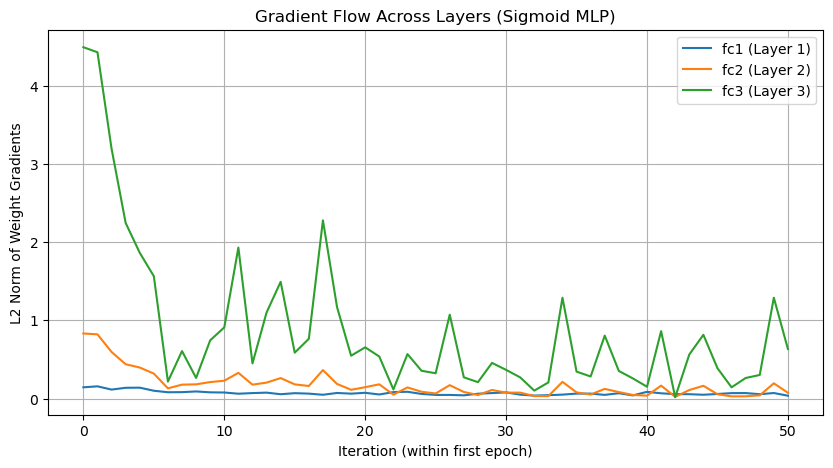

In [65]:
# Model Testing
save_path = "../Report/1_2_vanishing_gradients.png"
MLP_sigmoid_model = sigmoid_results["model"]
MLP_sigmoid_model.to(device)
predictions_test = MLP_sigmoid_model(X_test).squeeze(1)
test_loss = mse_loss(predictions_test, y_test)
print("MSE Loss (Test):", test_loss.item())

# Plotting Gradients in the First Epoch
plot_gradient_norms(gradient_store, save_path= save_path)

# 1.3 Imbalanced Threshold Classification

## Utility Functions

In [2]:
def compute_pr_metrics(probs, targets):
    import torch

    # Flatten
    probs = probs.view(-1)
    targets = targets.view(-1)

    # Sort by descending probability
    sorted_indices = torch.argsort(probs, descending=True)
    probs = probs[sorted_indices]
    targets = targets[sorted_indices]

    # Cumulative TP and FP
    tp = torch.cumsum(targets, dim=0)
    fp = torch.cumsum(1 - targets, dim=0)

    # Total positives
    total_pos = torch.sum(targets)

    # Precision and Recall
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (total_pos + 1e-8)

    # Add boundary points (important)
    precision = torch.cat([torch.tensor([1.0], device=precision.device), precision])
    recall = torch.cat([torch.tensor([0.0], device=recall.device), recall])

    # PR-AUC
    pr_auc = torch.trapz(precision, recall).item()

    return {
        "precision": precision,
        "recall": recall,
        "pr_auc": pr_auc
    }


def compute_pr_auc(precision, recall):
    import numpy as np

    # Ensure numpy arrays
    precision = np.asarray(precision)
    recall = np.asarray(recall)

    # Sort by recall (important for safety)
    sorted_idx = np.argsort(recall)
    recall = recall[sorted_idx]
    precision = precision[sorted_idx]

    # Trapezoidal integration
    pr_auc = np.trapz(precision, recall)

    return pr_auc

def loss_weights(y):
    num_pos = y.sum()
    num_neg = len(y) - num_pos
    return num_neg / (num_pos + 1e-8)

### Plotting Function

In [57]:
def plot_pr_curves(
    precision_1, recall_1,
    precision_2, recall_2,
    label_1="Model 1 (BCELoss)",
    label_2="Model 2 (Weighted BCE)",
    title="Precision-Recall Curve Comparison",
    save_path=None
):
    import numpy as np

    # --- Compute AUCs ---
    auc_1 = compute_pr_auc(precision_1, recall_1)
    auc_2 = compute_pr_auc(precision_2, recall_2)

    plt.figure(figsize=(8, 4))

    # Plot Model 1
    plt.plot(
        recall_1, precision_1,
        label=f"{label_1} (AUC = {auc_1:.4f})"
    )

    # Plot Model 2
    plt.plot(
        recall_2, precision_2,
        label=f"{label_2} (AUC = {auc_2:.4f})"
    )

    # Labels and title
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)

    # Grid and legend
    plt.grid(alpha=0.3)
    plt.legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

## Training Model

In [3]:
def train_full_batch_classification(
    model, X_train, y_train, X_val, y_val,
    save_path,
    epochs=100,
    lr=1e-3,
    patience=20,
    loss_fn=None,
    verbose=True
):
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import copy

    # --- Loss & Optimizer ---
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()  # numerically stable default
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Device ---
    # device = next(model.parameters()).device
    model.to(device)
    X_train, y_train = X_train.to(device), y_train.to(device)
    X_val, y_val = X_val.to(device), y_val.to(device)

    # --- Shape fix ---
    if len(y_train.shape) == 2:
        y_train = y_train.squeeze(1)
    if len(y_val.shape) == 2:
        y_val = y_val.squeeze(1)

    # --- Tracking ---
    best_pr_auc = -float("inf")
    best_model_state = None
    epochs_without_improvement = 0
    best_epoch = None

    train_losses = []
    val_losses = []
    val_pr_aucs = []

    # --- Training loop (FULL BATCH) ---
    for epoch in range(epochs):
        model.train()

        # --- Forward ---
        outputs_train = model(X_train).squeeze(1)
        train_loss = loss_fn(outputs_train, y_train)

        # --- Backprop ---
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            outputs_val = model(X_val).squeeze(1)
            val_loss = loss_fn(outputs_val, y_val)

            # Convert logits → probabilities if needed
            if isinstance(loss_fn, nn.BCEWithLogitsLoss):
                probs = torch.sigmoid(outputs_val)
            else:
                probs = outputs_val

            # --- PR-AUC ---
            metrics = compute_pr_metrics(probs, y_val)
            pr_auc = metrics["pr_auc"]

        # --- Store ---
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        val_pr_aucs.append(pr_auc)

        # --- Early stopping ---
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            best_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

        # --- Logging ---
        if verbose:
            print(
                f"Epoch [{epoch+1}/{epochs}] | "
                f"Train: {train_loss.item():.4f} | "
                f"Val: {val_loss.item():.4f} | "
                f"PR-AUC: {pr_auc:.4f} | "
                f"Best PR-AUC: {best_pr_auc:.4f}"
            )

    # --- Load best model ---
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"Best Model found at epoch: {best_epoch}")

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_pr_aucs": val_pr_aucs,
        "best_pr_auc": best_pr_auc
    }

## Model Classes

In [59]:
class MLP_relu_cat(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(MLP_relu_cat, self).__init__()
        self.layers = nn.Sequential(
                # Hidden Layer : 1 
                nn.Linear(input_size, hidden_size1),
                nn.ReLU(),
             
                # Hidden Layer : 2
                nn.Linear(hidden_size1, hidden_size2),
                nn.ReLU(),

                # Output Layer
                nn.Linear(hidden_size2, output_size),
                nn.Sigmoid()       # Sigmoid activation to output probabilities (0 to 1)
            )
        
        
    def forward(self,X):
        return self.layers(X)

## Driver Code

### Model 1

In [7]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase1_data = get_phase1_data(input_columns, target_columns)
X_train, y_train = phase1_data['train']
X_val, y_val = phase1_data['val']
X_test, y_test = phase1_data['test']

# Pre-processing Data
print()
print("Standard Transform applied on Data.")
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler_target = StandardScaler()

X_train = torch.tensor(std_scaler.fit_transform(X_train), dtype = torch.float32).to(device)
X_val = torch.tensor(std_scaler.transform(X_val), dtype = torch.float32).to(device)
X_test = torch.tensor(std_scaler.transform(X_test), dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

y_train_cat = (y_train >200).float()
y_val_cat = (y_val >200).float()
y_test_cat = (y_test >200).float()

Input Data Shape: (18776, 8)
Input Target Shape: (18776,)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143,)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817,)
Test Data Shape: (2816, 8)
Test Target Shape: (2816,)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 576)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 576)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 576)
Test Target Shape: (2720, 1)

Standard Transform applied on Data.


In [61]:
# MODEL 1: Using BCELoss (No Weights attached)
h_size1 = 128
h_size2 = 64

time_steps = 24
sliding_window = 72
input_dim = int(sliding_window * len(input_columns))

MLP_cat_model = MLP_relu_cat(input_size = input_dim, hidden_size1 = h_size1,
                hidden_size2 = h_size2, output_size = 1)


bce_loss = nn.BCELoss() # Loss 
learning_rate = 1e-3
optimizer = optim.Adam(MLP_cat_model.parameters(), lr = learning_rate) # Optimizer 
Epochs = int(400) # Epochs 
verbose_skip = 50 
patience = 15 # Number of epochs to wait for improvement

# Doing Batch GD
classification_model1_results = train_full_batch_classification(
    model=MLP_cat_model,
    X_train=X_train,
    y_train=y_train_cat,
    X_val=X_val,
    y_val=y_val_cat,
    save_path=save_path,
    epochs=Epochs,
    lr=learning_rate,
    patience=patience,

    loss_fn=bce_loss,   # since you're explicitly using BCELoss
    verbose=True
)

Epoch [1/400] | Train: 0.7068 | Val: 0.6276 | PR-AUC: 0.1809 | Best PR-AUC: 0.1809
Epoch [2/400] | Train: 0.6548 | Val: 0.5595 | PR-AUC: 0.1805 | Best PR-AUC: 0.1809
Epoch [3/400] | Train: 0.6192 | Val: 0.5023 | PR-AUC: 0.1793 | Best PR-AUC: 0.1809
Epoch [4/400] | Train: 0.5923 | Val: 0.4551 | PR-AUC: 0.1803 | Best PR-AUC: 0.1809
Epoch [5/400] | Train: 0.5725 | Val: 0.4200 | PR-AUC: 0.1769 | Best PR-AUC: 0.1809
Epoch [6/400] | Train: 0.5585 | Val: 0.3977 | PR-AUC: 0.1793 | Best PR-AUC: 0.1809
Epoch [7/400] | Train: 0.5487 | Val: 0.3853 | PR-AUC: 0.1830 | Best PR-AUC: 0.1830
Epoch [8/400] | Train: 0.5407 | Val: 0.3781 | PR-AUC: 0.1871 | Best PR-AUC: 0.1871
Epoch [9/400] | Train: 0.5329 | Val: 0.3730 | PR-AUC: 0.1925 | Best PR-AUC: 0.1925
Epoch [10/400] | Train: 0.5246 | Val: 0.3691 | PR-AUC: 0.1985 | Best PR-AUC: 0.1985
Epoch [11/400] | Train: 0.5163 | Val: 0.3673 | PR-AUC: 0.2046 | Best PR-AUC: 0.2046
Epoch [12/400] | Train: 0.5083 | Val: 0.3689 | PR-AUC: 0.2104 | Best PR-AUC: 0.2104
E

In [62]:
# Model Testing : MODEL 1
threshold = 0.5
MLP_cat_model = classification_model1_results["model"].to(device)
predictions_test = MLP_cat_model(X_test).squeeze(1) # Sigmoid Outputs

# --- Compute PR metrics ---
metrics_classification_model1 = compute_pr_metrics(predictions_test, y_test_cat)

### Model 2

In [8]:
input_columns = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
target_columns = 'pm2_5'

# Getting and Flattening Data
phase1_data = get_phase1_data(input_columns, target_columns)
X_train, y_train = phase1_data['train']
X_val, y_val = phase1_data['val']
X_test, y_test = phase1_data['test']

# Pre-processing Data
print()
print("Standard Transform applied on Data.")
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
std_scaler_target = StandardScaler()

X_train = torch.tensor(std_scaler.fit_transform(X_train), dtype = torch.float32).to(device)
X_val = torch.tensor(std_scaler.transform(X_val), dtype = torch.float32).to(device)
X_test = torch.tensor(std_scaler.transform(X_test), dtype = torch.float32).to(device)

y_train = torch.tensor(y_train, dtype = torch.float32).to(device)
y_val =  torch.tensor(y_val, dtype = torch.float32).to(device)
y_test = torch.tensor(y_test, dtype = torch.float32).to(device)

y_train_cat = (y_train >200).float()
y_val_cat = (y_val >200).float()
y_test_cat = (y_test >200).float()

Input Data Shape: (18776, 8)
Input Target Shape: (18776,)

########## Dimensions of Original Dataset ##########

Train Data Shape: (13143, 8)
Train Target Shape: (13143,)
Validation Data Shape: (2817, 8)
Validation Target Shape: (2817,)
Test Data Shape: (2816, 8)
Test Target Shape: (2816,)

########## Dimensions After Flattening ##########

Train Data Shape: (13047, 576)
Train Target Shape: (13047, 1)
Validation Data Shape: (2721, 576)
Validation Target Shape: (2721, 1)
Test Data Shape: (2720, 576)
Test Target Shape: (2720, 1)

Standard Transform applied on Data.


In [10]:
h_size1 = 128
h_size2 = 64

time_steps = 24
sliding_window = 72
input_dim = int(sliding_window * len(input_columns))
save_path = "../Models/1_3_classification.pth"
# Loss weights
loss_wt = torch.tensor(loss_weights(y_train_cat))
print(loss_wt)
bce_loss_wt = nn.BCEWithLogitsLoss(pos_weight= (loss_wt)) # Loss 

MLP_cat_model_2 = MLP_relu(input_size = input_dim, hidden_size1 = h_size1,
                hidden_size2 = h_size2, output_size = 1)

bce_loss_wt = nn.BCEWithLogitsLoss(pos_weight= (loss_wt)) # Loss 
learning_rate = 5e-4
# optimizer = optim.Adam(MLP_cat_model_2.parameters(), lr = learning_rate) # Optimizer 
# Epochs = int(400) # Epochs 
# verbose_skip = 25 
# patience = 15 # Number of epochs to wait for improvement

# classification_model2_results = train_full_batch_classification(
#     model=MLP_cat_model_2,
#     X_train=X_train,
#     y_train=y_train_cat,
#     X_val=X_val,
#     y_val=y_val_cat,
#     save_path=save_path,

#     epochs=Epochs,
#     lr=learning_rate,
#     patience=patience,

#     loss_fn=bce_loss_wt,   # since you're explicitly using BCELoss
#     verbose=True
# )

tensor(1.4210, device='mps:0')


NameError: name 'MLP_relu' is not defined

In [68]:
# Model Testing : MODEL 2
model2 = classification_model2_results["model"]

logits = model2(X_test).squeeze(1)
probs = torch.sigmoid(logits)

metrics_classification_model2 = compute_pr_metrics(probs, y_test_cat)

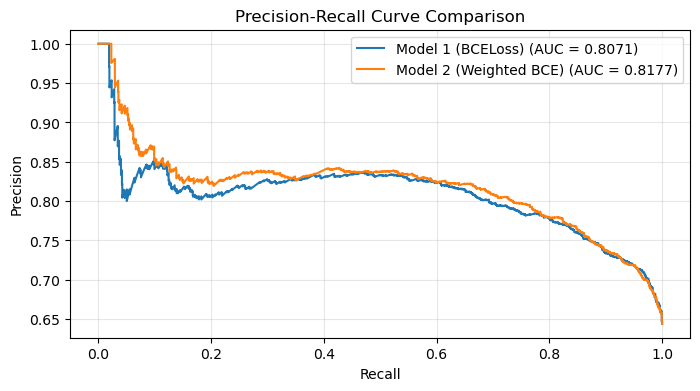

In [69]:
save_path = "../Report/1_3_2_comparison.png"
precision_1 =  metrics_classification_model1['precision'].detach().cpu().numpy()
recall_1 = metrics_classification_model1['recall'].detach().cpu().numpy()

precision_2 =  metrics_classification_model2['precision'].detach().cpu().numpy()
recall_2 = metrics_classification_model2['recall'].detach().cpu().numpy()

plot_pr_curves(precision_1,recall_1,
              precision_2, recall_2,save_path = save_path)